# Premier League Probability Engine

## Phase 1: Elo-rating baseline

This notebook builds a simple starting model for Premier League match prediction.

The aim is to estimate the probability of:

- A home win
- A draw
- An away win

using only historical match results availiable before each fixture.

The first verion will use Elo-ratings: a running numerical estimate of each team's strength. Later we will compare model probabilities with bookmaker odds and test hypothetical paper-trading signals.

For now, the onbjective is to simply understand the historical match data and build a clean baseline.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

pd.set_option('display.max_columns', 100)


## 1. Loading historical Premier League match data

Each row in the dataset represents one completed Premier League match.

For this first pass, we are using the 2024–25 season. The important columns are:

- `Date`: when the match was played
- `HomeTeam`: team playing at home
- `AwayTeam`: team playing away
- `FTHG`: full-time home goals
- `FTAG`: full-time away goals
- `FTR`: full-time result (`H` = home win, `D` = draw, `A` = away win)

Later, we will use the same dataset's bookmaker odds columns to compare the model's probabilities with market-implied probabilities.

In [12]:
url = "https://www.football-data.co.uk/mmz4281/2425/E0.csv"

matches = pd.read_csv(url)

print(f"Rows: {matches.shape[0]}")
print(f"Columns: {matches.shape[1]}")

matches.head()

Rows: 380
Columns: 120


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,BFH,BFD,BFA,PSH,PSD,PSA,WHH,WHD,WHA,1XBH,1XBD,1XBA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,BFEH,BFED,...,BFEAHH,BFEAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,BFCH,BFCD,BFCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,1XBCH,1XBCD,1XBCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,BFECH,BFECD,BFECA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,BFEC>2.5,BFEC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,E0,16/08/2024,20:00,Man United,Fulham,1,0,H,0,0,D,R Jones,14,10,5,2,12,10,7,8,2,3,0,0,1.60,4.20,5.25,1.60,4.4,5.25,1.60,4.33,5.00,1.63,4.38,5.30,1.65,4.2,5.00,1.68,4.32,5.03,1.68,4.50,5.50,1.62,4.36,5.15,1.66,4.5,...,2.10,1.88,1.67,4.10,5.00,1.65,4.20,4.80,1.62,4.0,5.00,1.65,4.23,5.28,1.60,4.2,5.50,1.66,4.15,5.33,1.70,4.33,5.50,1.66,4.20,5.02,1.72,4.20,5.40,1.62,2.30,1.63,2.38,1.66,2.45,1.61,2.37,1.68,2.46,-0.75,1.86,2.07,1.83,2.11,1.88,2.11,1.82,2.05,1.90,2.08
1,E0,17/08/2024,12:30,Ipswich,Liverpool,0,2,A,0,0,D,T Robinson,7,18,2,5,9,18,2,10,3,1,0,0,8.50,5.50,1.33,7.50,5.5,1.36,8.50,5.50,1.33,8.18,5.84,1.34,8.50,5.5,1.33,8.60,5.85,1.35,9.00,6.10,1.37,8.28,5.76,1.34,9.40,6.2,...,2.04,1.93,8.00,5.75,1.33,8.00,5.75,1.34,7.50,5.5,1.33,8.14,6.09,1.34,8.00,5.5,1.35,8.57,5.85,1.34,8.57,6.25,1.39,7.87,5.81,1.35,8.60,6.20,1.37,1.36,3.20,1.37,3.30,1.40,3.38,1.37,3.18,1.40,3.40,1.50,2.05,1.88,2.04,1.90,2.20,2.00,1.99,1.88,2.04,1.93
2,E0,17/08/2024,15:00,Arsenal,Wolves,2,0,H,1,0,H,J Gillett,18,9,6,3,17,14,8,2,2,2,0,0,1.18,7.50,13.00,1.20,7.5,13.50,1.15,8.00,16.00,1.16,8.56,16.22,1.18,7.0,17.00,1.20,7.65,16.00,1.20,9.10,18.00,1.18,7.86,15.87,1.19,9.0,...,1.94,2.00,1.14,8.50,15.00,1.16,8.50,18.00,1.13,8.5,17.00,1.15,9.05,18.76,1.15,8.0,19.00,1.16,9.39,16.60,1.17,9.40,21.00,1.15,8.62,18.11,1.17,9.40,21.00,1.40,3.00,1.41,2.98,1.45,3.00,1.42,2.93,1.44,3.20,-2.25,2.02,1.91,2.00,1.90,2.05,1.93,1.99,1.87,2.02,1.96
3,E0,17/08/2024,15:00,Everton,Brighton,0,3,A,0,1,A,S Hooper,9,10,1,5,8,8,1,5,1,1,1,0,2.63,3.30,2.63,2.65,3.4,2.60,2.70,3.40,2.63,2.73,3.36,2.71,2.60,3.5,2.70,2.68,3.66,2.63,2.76,3.66,2.78,2.67,3.41,2.68,2.78,3.5,...,1.99,1.99,3.10,3.40,2.30,3.00,3.40,2.37,3.00,3.3,2.30,3.15,3.41,2.40,3.10,3.3,2.40,3.16,3.47,2.34,3.16,3.50,2.45,3.06,3.40,2.38,3.15,3.55,2.46,1.93,1.97,1.93,1.97,1.95,2.00,1.89,1.96,1.94,2.04,0.25,1.87,2.06,1.86,2.07,1.92,2.10,1.83,2.04,1.88,2.11
4,E0,17/08/2024,15:00,Newcastle,Southampton,1,0,H,1,0,H,C Pawson,3,19,1,4,15,16,3,12,2,4,1,0,1.36,5.25,8.00,1.35,5.5,7.75,1.33,5.50,8.50,1.35,5.70,8.25,1.35,5.5,8.00,1.37,5.74,8.10,1.37,5.90,8.60,1.35,5.62,8.10,1.37,6.0,...,1.94,2.01,1.40,5.00,7.00,1.39,5.25,7.25,1.36,5.0,7.50,1.42,5.30,7.26,1.40,5.0,7.50,1.39,5.34,7.90,1.44,5.75,8.00,1.39,5.27,7.33,1.43,5.50,8.20,1.44,2.75,1.46,2.85,1.46,3.05,1.43,2.84,1.49,2.98,-1.25,1.87,2.06,1.88,2.06,1.89,2.10,1.82,2.05,1.89,2.10


In [13]:
core_columns = [
    "Date",
    "Time",
    "HomeTeam",
    "AwayTeam",
    "FTHG",
    "FTAG",
    "FTR",
]

matches_core = matches[core_columns].copy()

matches_core["Kickoff"] = pd.to_datetime(
    matches_core["Date"] + " " + matches_core["Time"],
    dayfirst=True,
)

matches_core["Date"] = pd.to_datetime(
    matches_core["Date"],
    dayfirst=True,
)

matches_core.head(15)

,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,Kickoff
0,2024-08-16,20:00,Man United,Fulham,1,0,H,2024-08-16 20:00:00
1,2024-08-17,12:30,Ipswich,Liverpool,0,2,A,2024-08-17 12:30:00
2,2024-08-17,15:00,Arsenal,Wolves,2,0,H,2024-08-17 15:00:00
3,2024-08-17,15:00,Everton,Brighton,0,3,A,2024-08-17 15:00:00
4,2024-08-17,15:00,Newcastle,Southampton,1,0,H,2024-08-17 15:00:00
5,2024-08-17,15:00,Nott'm Forest,Bournemouth,1,1,D,2024-08-17 15:00:00
6,2024-08-17,17:30,West Ham,Aston Villa,1,2,A,2024-08-17 17:30:00
7,2024-08-18,14:00,Brentford,Crystal Palace,2,1,H,2024-08-18 14:00:00
8,2024-08-18,16:30,Chelsea,Man City,0,2,A,2024-08-18 16:30:00
9,2024-08-19,20:00,Leicester,Tottenham,1,1,D,2024-08-19 20:00:00


### Data checks

Before using the match results in a model, we first check that the columns are complete and that the dataset contains the expected number of teams.

The Elo model will assign one numerical strength rating to each team. Missing match results or inconsistent team names would make those ratings unreliable, so these checks are a simple first validation step.

The code below: 

- Checks for missing values in the six columns used by the baseline model;
- combines the home-team and away-team columns;
- removes duplicate names;
- confirms that the season contains 20 unique Premier League teams.

In [14]:
print("Missing values:")
print(matches_core.isna().sum())

print("\nNumber of unique teams:")
print(len(set(matches_core["HomeTeam"]) | set(matches_core["AwayTeam"])))

print("\nTeams:")
print(
    sorted(
        set(matches_core["HomeTeam"]) | set(matches_core["AwayTeam"])
    )
)

Missing values:
Date        0
Time        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
Kickoff     0
dtype: int64

Number of unique teams:
20

Teams:
['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Ipswich', 'Leicester', 'Liverpool', 'Man City', 'Man United', 'Newcastle', "Nott'm Forest", 'Southampton', 'Tottenham', 'West Ham', 'Wolves']


### Initial data validation result

The six core match-result columns contain no missing values, and the dataset contains 20 unique teams. This is consistent with a complete Premier League dataset and gives the Elo model a clean set of teams to initialise and update over time.

## 2. Basic season summary

Before fitting a model, it is useful to understand the outcomes that the model will try to predict.

This section summarises:

- how often home teams won or lost;
- average goals scored by home and away teams;
- whether data suggests a home advantage.

In [15]:
result_names = {
    "H" : "Home Win",
    "D" : "Draw",
    "A" : "Away Win"
}

result_counts = matches_core["FTR"].value_counts().rename(index=result_names)

summary = pd.DataFrame({
    "Result": result_counts.index,
    "Count": result_counts.values,
    "Percentage": (result_counts.values / len(matches_core)) * 100
})

summary

,Result,Count,Percentage
0,Home Win,155,40.789474
1,Away Win,132,34.736842
2,Draw,93,24.473684


### Initial result: home advantage

Home teams won $40.8$% of matches in the 2024-25 Premier League season, compared to a $34.7$% win rate for away teams.

This suggests that match location provides some useful predictive information. The baseline model should therefore include a home-advantage adjustment rather than treating home and away fixtures symmetrically.

Draws accounted for $24.5$% of matches. Because football has three possible outcomes: win, draw and loss, the model will ultimately need to assign probabilitiies to home wins, draws and away wins rather than producing only a single win probability.

### Average goals by match location

The result summary showed that home teams won more often than away teams.

Average goals give another way to check for home advantage. If on average home teams score more goals, that will support including match location in the prediction model.

This is only a descriptive summary. It does not prove that every team is stronger at home, but it gives us an overall league-level pattern to look out for.

In [16]:
average_goals = pd.DataFrame({
    "Match location": ["Home teams", "Away teams"],
    "Average goals scored": [
        matches_core["FTHG"].mean(),
        matches_core["FTAG"].mean(),
    ],
})

average_goals["Average goals scored"] = (
    average_goals["Average goals scored"].round(2)
)

average_goals

,Match location,Average goals scored
0,Home teams,1.51
1,Away teams,1.42


### Initial result: scoring and home advantage

Home teams scored an average of $1.51$ goals per match, compared with $1.42$ for away teams.

Together with the higher home-win rate, this supports treating home advantage as a real feature of the data. Home teams won approximately $18$% more often than away teams, and scored around $6$% more goals on average, further supporting the use of match location in the prediction model. In the Elo model, the home team will receive a small rating adjustment before the match probabilities are calculated.

This adjustment will be learned through a simple modelling assumption at first, then tested later to see whether it improves predictions.

### Team scoring profiles

The league-wide averages show a small home advantage, but they do not show how much teams differ from one another.

The plot below compares each team's average goals scored at home with its average goals scored away. The vertical and horizontal reference lines show the overall league averages.

Teams in the top-right quadrant score above the league average both at home and away. This is a descriptive view of attacking performance over one season, rather than a prediction model.

In [17]:
home_scoring = (
    matches_core.groupby("HomeTeam")["FTHG"]
    .mean()
    .rename("Average home goals")
)

away_scoring = (
    matches_core.groupby("AwayTeam")["FTAG"]
    .mean()
    .rename("Average away goals")
)

team_scoring = pd.concat(
    [home_scoring, away_scoring],
    axis=1,
)

league_home_average = matches_core["FTHG"].mean()
league_away_average = matches_core["FTAG"].mean()

team_scoring.head()

,Average home goals,Average away goals
Arsenal,1.842105,1.789474
Aston Villa,1.789474,1.263158
Bournemouth,1.210526,1.842105
Brentford,2.105263,1.368421
Brighton,1.578947,1.894737


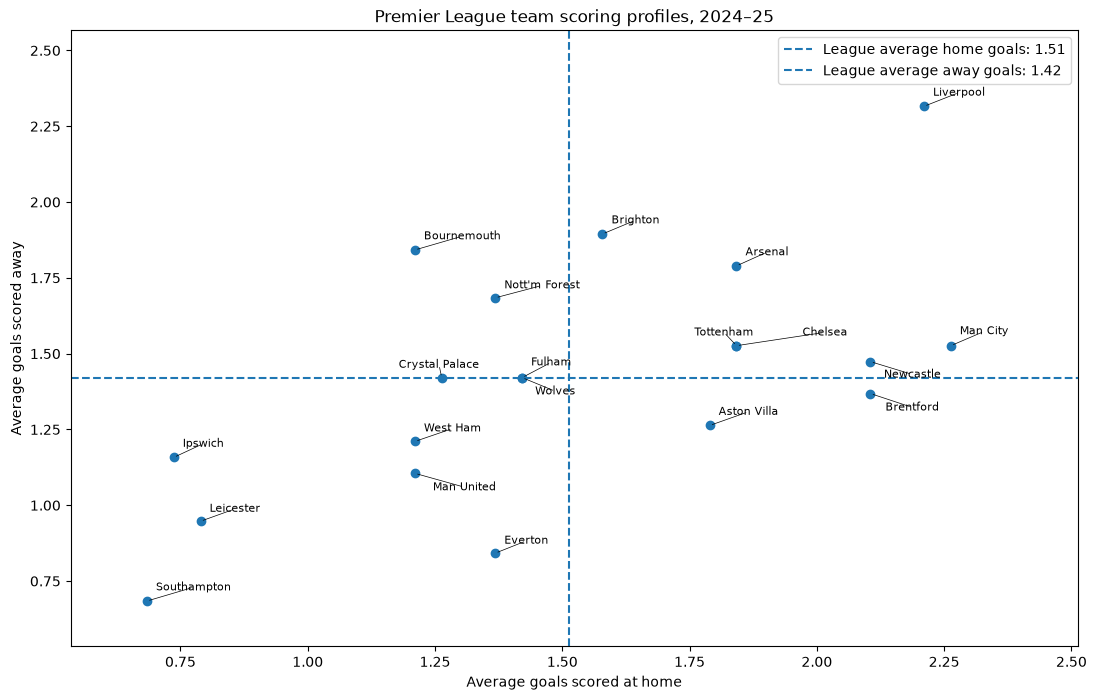

In [18]:
plt.figure(figsize=(13, 8))

plt.scatter(
    team_scoring["Average home goals"],
    team_scoring["Average away goals"],
)

texts = []

for team, row in team_scoring.iterrows():
    text = plt.text(
        row["Average home goals"],
        row["Average away goals"],
        team,
        fontsize=8,
    )
    texts.append(text)

plt.axvline(
    league_home_average,
    linestyle="--",
    label=f"League average home goals: {league_home_average:.2f}",
)

plt.axhline(
    league_away_average,
    linestyle="--",
    label=f"League average away goals: {league_away_average:.2f}",
)

plt.xlabel("Average goals scored at home")
plt.ylabel("Average goals scored away")
plt.title("Premier League team scoring profiles, 2024–25")

plt.xlim(
    team_scoring["Average home goals"].min() - 0.15,
    team_scoring["Average home goals"].max() + 0.25,
)

plt.ylim(
    team_scoring["Average away goals"].min() - 0.15,
    team_scoring["Average away goals"].max() + 0.25,
)

adjust_text(
    texts,
    expand=(1.8, 2.2),
    force_text=(1.2, 1.5),
    force_points=(0.4, 0.6),
    arrowprops={
        "arrowstyle": "-",
        "linewidth": 0.5,
    },
)

plt.legend()
plt.show()

## 3. Reconstructing the final league table

Before building an Elo model, we can reconstruct the final league table from the raw match results.

This is not used as a prediction feature, because the final table uses information from the whole season. However, it is useful for checking that the data behaves as expected and for creating a simple benchmark against which future ratings can be compared.

In [19]:
teams = sorted(
    set(matches_core["HomeTeam"]) | set(matches_core["AwayTeam"])
)

league_table = pd.DataFrame(
    0,
    index=teams,
    columns=[
        "Played",
        "Wins",
        "Draws",
        "Losses",
        "Goals For",
        "Goals Against",
        "Points",
    ],
)

for _, match in matches_core.iterrows():
    home_team = match["HomeTeam"]
    away_team = match["AwayTeam"]
    home_goals = match["FTHG"]
    away_goals = match["FTAG"]

    league_table.loc[home_team, "Played"] += 1
    league_table.loc[away_team, "Played"] += 1

    league_table.loc[home_team, "Goals For"] += home_goals
    league_table.loc[home_team, "Goals Against"] += away_goals

    league_table.loc[away_team, "Goals For"] += away_goals
    league_table.loc[away_team, "Goals Against"] += home_goals

    if home_goals > away_goals:
        league_table.loc[home_team, "Wins"] += 1
        league_table.loc[away_team, "Losses"] += 1
        league_table.loc[home_team, "Points"] += 3

    elif home_goals < away_goals:
        league_table.loc[away_team, "Wins"] += 1
        league_table.loc[home_team, "Losses"] += 1
        league_table.loc[away_team, "Points"] += 3

    else:
        league_table.loc[home_team, "Draws"] += 1
        league_table.loc[away_team, "Draws"] += 1
        league_table.loc[home_team, "Points"] += 1
        league_table.loc[away_team, "Points"] += 1

league_table["Goal Difference"] = (
    league_table["Goals For"] - league_table["Goals Against"]
)

league_table = league_table.sort_values(
    by=["Points", "Goal Difference", "Goals For"],
    ascending=False,
)

league_table

,Played,Wins,Draws,Losses,Goals For,Goals Against,Points,Goal Difference
Liverpool,38,25,9,4,86,41,84,45
Arsenal,38,20,14,4,69,34,74,35
Man City,38,21,8,9,72,44,71,28
Chelsea,38,20,9,9,64,43,69,21
Newcastle,38,20,6,12,68,47,66,21
Aston Villa,38,19,9,10,58,51,66,7
Nott'm Forest,38,19,8,11,58,46,65,12
Brighton,38,16,13,9,66,59,61,7
Bournemouth,38,15,11,12,58,46,56,12
Brentford,38,16,8,14,66,57,56,9


### League table check

The reconstructed table gives a useful sanity check on the match data. Each team has played 38 matches, and the ranking broadly reflects the season outcome.

This table is descriptive rather than predictive. It uses the whole season, so it would create look-ahead bias if used directly to predict earlier matches. The Elo model will avoid this by updating team ratings chronologically after each match.

## 4. Chronological match ordering

The final league table uses the full season and is only descriptive.

For Elo ratings, the order of matches matters. Ratings must be updated after each match using only information available up to that point. Sorting matches by kickoff time helps prevent look-ahead bias before the Elo model is built.

In [20]:
matches_chronological = matches_core.sort_values(
    "Kickoff"
).reset_index(drop=True)

matches_chronological[
    [
        "Kickoff",
        "HomeTeam",
        "AwayTeam",
        "FTHG",
        "FTAG",
        "FTR",
    ]
].head(10)

,Kickoff,HomeTeam,AwayTeam,FTHG,FTAG,FTR
0,2024-08-16 20:00:00,Man United,Fulham,1,0,H
1,2024-08-17 12:30:00,Ipswich,Liverpool,0,2,A
2,2024-08-17 15:00:00,Arsenal,Wolves,2,0,H
3,2024-08-17 15:00:00,Everton,Brighton,0,3,A
4,2024-08-17 15:00:00,Newcastle,Southampton,1,0,H
5,2024-08-17 15:00:00,Nott'm Forest,Bournemouth,1,1,D
6,2024-08-17 17:30:00,West Ham,Aston Villa,1,2,A
7,2024-08-18 14:00:00,Brentford,Crystal Palace,2,1,H
8,2024-08-18 16:30:00,Chelsea,Man City,0,2,A
9,2024-08-19 20:00:00,Leicester,Tottenham,1,1,D


In [21]:
print(
    "Matches are in chronological order:",
    matches_chronological["Kickoff"].is_monotonic_increasing,
)

print(
    "Number of matches:",
    len(matches_chronological),
)

Matches are in chronological order: True
Number of matches: 380


## 5. Elo rating baseline

The next step is to build a simple Elo rating system.

Elo gives every team a numerical strength rating. Teams start at the same rating, then ratings update after each match depending on whether the result was expected or surprising.

This first version uses:
- an initial rating of 1500 for every team;
- a K-factor controlling how quickly ratings update;
- a home-advantage adjustment added to the home team's rating before a match.

In [22]:
initial_rating = 1500
k_factor = 20
home_advantage = 50

teams = sorted(
    set(matches_chronological["HomeTeam"]) | set(matches_chronological["AwayTeam"])
)

elo_ratings = {
    team: initial_rating
    for team in teams
}

pd.DataFrame(
    {
        "Team": elo_ratings.keys(),
        "Initial Elo rating": elo_ratings.values(),
    }
).head(10)

,Team,Initial Elo rating
0,Arsenal,1500
1,Aston Villa,1500
2,Bournemouth,1500
3,Brentford,1500
4,Brighton,1500
5,Chelsea,1500
6,Crystal Palace,1500
7,Everton,1500
8,Fulham,1500
9,Ipswich,1500


In [23]:
def expected_score(team_rating, opponent_rating):
    return 1 / (1 + 10 ** ((opponent_rating - team_rating) / 400))


home_expected_score = expected_score(
    initial_rating + home_advantage,
    initial_rating,
)

away_expected_score = 1 - home_expected_score

print(f"Home expected score: {home_expected_score:.3f}")
print(f"Away expected score: {away_expected_score:.3f}")

Home expected score: 0.571
Away expected score: 0.429


The Elo expected-score formula converts a rating difference into an expected result between 0 and 1. Equal ratings produce an expected score of 0.5. Larger rating advantages produce expected scores closer to 1.

In football, the expected score is not yet the same as a home-win/draw/away-win probability. It treats a win as 1, a draw as 0.5 and a loss as 0. This makes it useful for updating ratings after each match.

### Manual Elo update for one match

Before applying Elo to the full season, it helps to update ratings for one match manually.

This shows the core logic:
1. read the two teams' current ratings;
2. add home advantage to the home team's rating when calculating expectations;
3. convert the rating difference into expected scores;
4. compare expected scores with the actual result;
5. update both teams' ratings.

In [24]:
example_match = matches_chronological.iloc[0]

home_team = example_match["HomeTeam"]
away_team = example_match["AwayTeam"]
home_goals = example_match["FTHG"]
away_goals = example_match["FTAG"]

home_rating = elo_ratings[home_team]
away_rating = elo_ratings[away_team]

home_expected = expected_score(
    home_rating + home_advantage,
    away_rating,
)

away_expected = 1 - home_expected

if home_goals > away_goals:
    home_actual = 1
    away_actual = 0
elif home_goals < away_goals:
    home_actual = 0
    away_actual = 1
else:
    home_actual = 0.5
    away_actual = 0.5

home_new_rating = home_rating + k_factor * (home_actual - home_expected)
away_new_rating = away_rating + k_factor * (away_actual - away_expected)

print(f"Match: {home_team} {home_goals}-{away_goals} {away_team}")
print(f"{home_team} old rating: {home_rating:.1f}")
print(f"{away_team} old rating: {away_rating:.1f}")
print(f"{home_team} expected score: {home_expected:.3f}")
print(f"{away_team} expected score: {away_expected:.3f}")
print(f"{home_team} new rating: {home_new_rating:.1f}")
print(f"{away_team} new rating: {away_new_rating:.1f}")

Match: Man United 1-0 Fulham
Man United old rating: 1500.0
Fulham old rating: 1500.0
Man United expected score: 0.571
Fulham expected score: 0.429
Man United new rating: 1508.6
Fulham new rating: 1491.4


### Converting football results into Elo scores

Elo updates ratings by comparing actual performance with expected performance.

In football, the match result must first be converted into an Elo score:

- win = 1
- draw = 0.5
- loss = 0

This helper function takes the home and away goals from a match and returns the actual Elo score for both teams.

In [25]:
def actual_scores_from_goals(home_goals, away_goals):
    if home_goals > away_goals:
        return 1, 0

    elif home_goals < away_goals:
        return 0, 1

    else:
        return 0.5, 0.5

In [26]:
example_match = matches_chronological.iloc[0]

home_actual, away_actual = actual_scores_from_goals(
    example_match["FTHG"],
    example_match["FTAG"],
)

print("Match:")
print(
    example_match["HomeTeam"],
    example_match["FTHG"],
    "-",
    example_match["FTAG"],
    example_match["AwayTeam"],
)

print(f"Home actual Elo score: {home_actual}")
print(f"Away actual Elo score: {away_actual}")

Match:
Man United 1 - 0 Fulham
Home actual Elo score: 1
Away actual Elo score: 0
